In [1]:
import numpy as np
import scipy.sparse as sp
from collections import defaultdict
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import psutil
import os
import time

In [2]:
def read_interactions(path):
    user2idx = {}
    item2idx = {}
    idx2user = []
    idx2item = []
    rows = []
    cols = []
    data = []
    user_items = defaultdict(set)
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            user_id = parts[0]
            item_ids = parts[1:]
            if user_id not in user2idx:
                user2idx[user_id] = len(idx2user)
                idx2user.append(user_id)
            u = user2idx[user_id]
            for item_id in item_ids:
                if item_id not in item2idx:
                    item2idx[item_id] = len(idx2item)
                    idx2item.append(item_id)
                i = item2idx[item_id]
                rows.append(u)
                cols.append(i)
                data.append(1.0)
                user_items[u].add(i)
    num_users = len(idx2user)
    num_items = len(idx2item)
    interaction_matrix = sp.coo_matrix((data, (rows, cols)), shape=(num_users, num_items)).tocsr()
    return interaction_matrix, idx2user, idx2item, user_items

In [3]:
def build_adj_matrix(num_users, num_items, user_items):
    num_nodes = num_users + num_items
    row = []
    col = []
    for u, items in user_items.items():
        for i in items:
            ui = u
            ii = num_users + i
            row.append(ui)
            col.append(ii)
            row.append(ii)
            col.append(ui)
    indices = np.vstack([row, col])
    data = np.ones(len(row), dtype=np.float32)
    adj = sp.coo_matrix((data, (indices[0], indices[1])), shape=(num_nodes, num_nodes))
    rowsum = np.array(adj.sum(1)).flatten()
    rowsum[rowsum == 0.0] = 1.0
    d_inv_sqrt = np.power(rowsum, -0.5)
    d_inv_sqrt_mat = sp.diags(d_inv_sqrt)
    norm_adj = d_inv_sqrt_mat.dot(adj).dot(d_inv_sqrt_mat).tocoo()
    indices_torch = torch.LongTensor([norm_adj.row, norm_adj.col])
    values_torch = torch.FloatTensor(norm_adj.data)
    shape = torch.Size(norm_adj.shape)
    adj_torch = torch.sparse.FloatTensor(indices_torch, values_torch, shape)
    return adj_torch

In [4]:
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim, num_layers, adj):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_nodes = num_users + num_items
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.adj = adj
        self.embeddings = nn.Embedding(self.num_nodes, embedding_dim)
        nn.init.normal_(self.embeddings.weight, std=0.01)

    def propagate(self):
        all_emb = self.embeddings.weight
        embs = [all_emb]
        for _ in range(self.num_layers):
            all_emb = torch.sparse.mm(self.adj, all_emb)
            embs.append(all_emb)
        embs_stack = torch.stack(embs, dim=0)
        out = torch.mean(embs_stack, dim=0)
        users = out[:self.num_users]
        items = out[self.num_users:]
        return users, items

    def forward(self):
        return self.propagate()

    def bpr_loss(self, users_idx, pos_idx, neg_idx, reg):
        users_emb, items_emb = self.propagate()
        u_e = users_emb[users_idx]
        p_e = items_emb[pos_idx]
        n_e = items_emb[neg_idx]
        pos_scores = torch.sum(u_e * p_e, dim=1)
        neg_scores = torch.sum(u_e * n_e, dim=1)
        loss = -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))
        reg_loss = (u_e.norm(2).pow(2) + p_e.norm(2).pow(2) + n_e.norm(2).pow(2)) / users_idx.shape[0]
        return loss + reg * reg_loss

In [5]:
def ndcg_at_k(relevance, k=20):
    relevance = np.asfarray(relevance)[:k]
    if relevance.size == 0:
        return 0.0
    # DCG
    gains = (2.0 ** relevance - 1.0) / np.log2(np.arange(2, relevance.size + 2))
    dcg = np.sum(gains)
    # IDCG
    ideal_relevance = np.sort(relevance)[::-1]
    ideal_gains = (2.0 ** ideal_relevance - 1.0) / np.log2(np.arange(2, ideal_relevance.size + 2))
    idcg = np.sum(ideal_gains)
    if idcg <= 0.0:
        return 0.0
    return float(dcg / idcg)


def evaluate_ndcg_at_k(model, train_user_items, val_user_items, num_users, num_items, k=20, device="cpu"):
    model.eval()
    ndcgs = []
    with torch.no_grad():
        users_emb, items_emb = model.propagate()
        users_emb = users_emb.to(device)
        items_emb = items_emb.to(device)

        for u in range(num_users):
            val_items = val_user_items.get(u, set())
            if not val_items:
                continue

            u_vec = users_emb[u]
            scores = (items_emb @ u_vec).cpu().numpy()

            # Mask training items
            seen_train = train_user_items.get(u, set())
            for i in seen_train:
                if 0 <= i < num_items:
                    scores[i] = -1e9

            # Top-k indices
            if k >= num_items:
                top_idx = np.argsort(-scores)
            else:
                part = np.argpartition(-scores, k)[:k]
                top_idx = part[np.argsort(-scores[part])]
            top_idx = top_idx[:k]

            # Binary relevance: 1 if in validation set
            rel = [1.0 if i in val_items else 0.0 for i in top_idx]
            ndcgs.append(ndcg_at_k(rel, k))

    return float(np.mean(ndcgs)) if ndcgs else 0.0


def split_train_val(user_items, val_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    train_ui = defaultdict(set)
    val_ui = defaultdict(set)

    for u, items in user_items.items():
        items_list = list(items)
        if len(items_list) <= 1:
            train_ui[u].update(items_list)
            continue

        n_val = max(1, int(len(items_list) * val_ratio))
        val_indices = rng.choice(len(items_list), size=n_val, replace=False)
        val_set = {items_list[i] for i in val_indices}
        train_set = set(items_list) - val_set

        if not train_set:
            # if all items went to val, keep one for train
            train_set = {items_list[0]}
            val_set = set(items_list[1:])

        train_ui[u].update(train_set)
        if val_set:
            val_ui[u].update(val_set)

    return train_ui, val_ui


def sample_batch(user_items, num_users, num_items, batch_size, device):
    users = []
    pos_items = []
    neg_items = []
    valid_users = [u for u in range(num_users) if len(user_items.get(u, [])) > 0]
    valid_users = np.array(valid_users)
    for _ in range(batch_size):
        u = int(np.random.choice(valid_users))
        pos_list = list(user_items[u])
        pi = int(np.random.choice(pos_list))
        while True:
            ni = int(np.random.randint(0, num_items))
            if ni not in user_items[u]:
                break
        users.append(u)
        pos_items.append(pi)
        neg_items.append(ni)
    users = torch.LongTensor(users).to(device)
    pos_items = torch.LongTensor(pos_items).to(device)
    neg_items = torch.LongTensor(neg_items).to(device)
    return users, pos_items, neg_items


def train_lightgcn(
    interaction_matrix,
    train_user_items,
    val_user_items,
    embedding_dim=128,
    num_layers=3,
    epochs=150,
    batch_size=4096,
    lr=0.001,
    reg=1e-4,
    patience=8,
    device="cpu"
):
    num_users, num_items = interaction_matrix.shape
    adj = build_adj_matrix(num_users, num_items, train_user_items).to(device)
    model = LightGCN(num_users, num_items, embedding_dim, num_layers, adj).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    steps_per_epoch = max(num_users * 5 // batch_size, 1)

    # For tracking best NDCG@20 (main metric)
    best_ndcg = -float("inf")
    best_state_dict = None
    no_improve = 0

    # For plotting training curves and system usage
    process = psutil.Process(os.getpid())
    process.cpu_percent(interval=None)  # initialize

    history = {
        "epoch": [],
        "loss": [],
        "ndcg@20": [],
        "cpu_percent": [],
        "memory_mb": [],
        "epoch_time_sec": [],
    }

    for epoch in range(epochs):
        epoch_start_time = time.time()

        model.train()
        total_loss = 0.0

        for _ in range(steps_per_epoch):
            users_idx, pos_idx, neg_idx = sample_batch(train_user_items, num_users, num_items, batch_size, device)
            optimizer.zero_grad()
            loss = model.bpr_loss(users_idx, pos_idx, neg_idx, reg)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch

        # Evaluate NDCG@20 on validation split
        ndcg20 = evaluate_ndcg_at_k(
            model,
            train_user_items=train_user_items,
            val_user_items=val_user_items,
            num_users=num_users,
            num_items=num_items,
            k=20,
            device=device,
        )

        # System stats
        cpu_percent = process.cpu_percent(interval=None)
        mem_mb = process.memory_info().rss / (1024.0 ** 2)
        epoch_time = time.time() - epoch_start_time

        # Save history for plots
        history["epoch"].append(epoch + 1)
        history["loss"].append(avg_loss)
        history["ndcg@20"].append(ndcg20)
        history["cpu_percent"].append(cpu_percent)
        history["memory_mb"].append(mem_mb)
        history["epoch_time_sec"].append(epoch_time)

        print(
            f"epoch {epoch+1}, loss {avg_loss:.4f}, "
            f"NDCG@20 {ndcg20:.4f}, "
            f"CPU {cpu_percent:.1f}%, "
            f"Mem {mem_mb:.1f} MB, "
            f"time {epoch_time:.2f}s"
        )

        # Early stopping based on NDCG@20
        if ndcg20 > best_ndcg + 1e-4:
            best_ndcg = ndcg20
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("early stopping (NDCG@20 did not improve)")
                break

    # Load best model (by NDCG@20)
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history

In [6]:
def compute_item_popularity(user_items, num_items):
    pop = np.zeros(num_items, dtype=np.int64)
    for _, items in user_items.items():
        for i in items:
            pop[i] += 1
    return pop


def avg_pos_neg_score(model, interaction_matrix, user_items, num_samples=1000, device="cpu"):
    num_users, num_items = interaction_matrix.shape
    model.eval()
    with torch.no_grad():
        users_emb, items_emb = model.propagate()
        users_emb = users_emb.to(device)
        items_emb = items_emb.to(device)
        pos_scores = []
        neg_scores = []
        rng = np.random.default_rng(42)
        valid_users = [u for u in range(num_users) if len(user_items.get(u, [])) > 0]
        for _ in range(num_samples):
            u = int(rng.choice(valid_users))
            pos_list = list(user_items[u])
            pi = int(rng.choice(pos_list))
            while True:
                ni = int(rng.integers(0, num_items))
                if ni not in user_items[u]:
                    break
            u_vec = users_emb[u]
            pos_scores.append((u_vec * items_emb[pi]).sum().item())
            neg_scores.append((u_vec * items_emb[ni]).sum().item())
    return np.mean(pos_scores), np.mean(neg_scores)

In [7]:
def generate_recommendations(
    model,
    user_items,
    idx2user,
    idx2item,
    item_popularity,
    top_k=20,
    output_path="submission-lgcn4-new.txt",
    alpha=0.8,
    device="cpu"
):
    model.eval()
    with torch.no_grad():
        users_emb, items_emb = model.propagate()
        users_emb = users_emb.to(device)
        items_emb = items_emb.to(device)
        num_users = users_emb.shape[0]
        num_items = items_emb.shape[0]
        pop_norm = item_popularity.astype(np.float32)
        if pop_norm.max() > 0:
            pop_norm = pop_norm / pop_norm.max()
        with open(output_path, "w") as out_f:
            for u in range(num_users):
                user_id = idx2user[u]
                u_vec = users_emb[u]
                scores_cf = (items_emb @ u_vec).cpu().numpy()
                scores_pop = pop_norm[:num_items]
                scores = alpha * scores_cf + (1.0 - alpha) * scores_pop
                seen = user_items.get(u, set())
                for i in seen:
                    if 0 <= i < num_items:
                        scores[i] = -1e9
                if top_k >= num_items:
                    top_indices = np.argsort(-scores)
                else:
                    part = np.argpartition(-scores, top_k)[:top_k]
                    top_indices = part[np.argsort(-scores[part])]
                top_indices = top_indices[:top_k]
                rec_ids = [idx2item[i] for i in top_indices]
                out_f.write(" ".join([user_id] + rec_ids) + "\n")

In [8]:
def generate_popularity_only(user_items, idx2user, idx2item, item_popularity, top_k=20, output_path="submission_pop.txt"):
    num_users = len(idx2user)
    num_items = len(idx2item)
    order = np.argsort(-item_popularity)[:num_items]
    with open(output_path, "w") as out_f:
        for u in range(num_users):
            user_id = idx2user[u]
            seen = user_items.get(u, set())
            recs = []
            for i in order:
                if i in seen:
                    continue
                recs.append(idx2item[i])
                if len(recs) >= top_k:
                    break
            out_f.write(" ".join([user_id] + recs) + "\n")

In [9]:
interaction_matrix, idx2user, idx2item, user_items = read_interactions("/Users/hemanthsai/Downloads/train-1.txt")

print("interaction_matrix shape:", interaction_matrix.shape)
print("num users:", len(idx2user))
print("num items:", len(idx2item))

# Train/validation split for NDCG@20
train_user_items, val_user_items = split_train_val(user_items, val_ratio=0.1, seed=42)
print("users with train interactions:", sum(1 for u in train_user_items if len(train_user_items[u]) > 0))
print("users with val interactions:", sum(1 for u in val_user_items if len(val_user_items[u]) > 0))

interaction_matrix shape: (31668, 38048)
num users: 31668
num items: 38048
users with train interactions: 31668
users with val interactions: 31668


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, history = train_lightgcn(
    interaction_matrix,
    train_user_items=train_user_items,
    val_user_items=val_user_items,
    embedding_dim=128,
    num_layers=3,
    epochs=150,
    batch_size=4096,
    lr=0.001,
    reg=1e-4,
    patience=8,
    device=device
)

/var/folders/9c/pw_b8z516z1gvcf9004z7fbh0000gn/T/ipykernel_26966/3803967282.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  indices_torch = torch.LongTensor([norm_adj.row, norm_adj.col])
/var/folders/9c/pw_b8z516z1gvcf9004z7fbh0000gn/T/ipykernel_26966/3803967282.py:24: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:646.)
  adj_torch = torch.sparse.FloatTensor(indices_torch, values_torch, shape)


epoch 1, loss 0.6892, NDCG@20 0.0489, CPU 230.7%, Mem 474.1 MB, time 31.85s
epoch 2, loss 0.6140, NDCG@20 0.0480, CPU 232.5%, Mem 558.8 MB, time 32.28s
epoch 3, loss 0.4411, NDCG@20 0.0479, CPU 233.0%, Mem 466.4 MB, time 32.81s
epoch 4, loss 0.3053, NDCG@20 0.0481, CPU 232.2%, Mem 555.9 MB, time 33.39s
epoch 5, loss 0.2389, NDCG@20 0.0485, CPU 235.2%, Mem 520.6 MB, time 32.83s
epoch 6, loss 0.2061, NDCG@20 0.0487, CPU 234.8%, Mem 537.8 MB, time 33.14s
epoch 7, loss 0.1866, NDCG@20 0.0488, CPU 234.8%, Mem 516.5 MB, time 33.31s
epoch 8, loss 0.1786, NDCG@20 0.0492, CPU 234.7%, Mem 325.3 MB, time 33.74s
epoch 9, loss 0.1706, NDCG@20 0.0492, CPU 232.5%, Mem 526.9 MB, time 34.44s
epoch 10, loss 0.1672, NDCG@20 0.0494, CPU 239.6%, Mem 531.6 MB, time 32.70s
epoch 11, loss 0.1653, NDCG@20 0.0495, CPU 234.8%, Mem 563.0 MB, time 34.52s
epoch 12, loss 0.1586, NDCG@20 0.0499, CPU 233.2%, Mem 448.6 MB, time 34.83s
epoch 13, loss 0.1572, NDCG@20 0.0501, CPU 239.5%, Mem 549.8 MB, time 33.96s
epoch 14

In [11]:
# Still computing these stats (optional, not main metric)
pos_mean, neg_mean = avg_pos_neg_score(model, interaction_matrix, train_user_items, device=device)
print("avg pos score:", pos_mean)
print("avg neg score:", neg_mean)

avg pos score: 5.908637810826302
avg neg score: 0.15611586640775205


In [12]:
num_users, num_items = interaction_matrix.shape
item_popularity = compute_item_popularity(user_items, num_items)

In [13]:
generate_recommendations(
    model,
    user_items,
    idx2user,
    idx2item,
    item_popularity,
    top_k=20,
    output_path="submission_lgcn4-new.txt",
    alpha=0.8,
    device=device
)

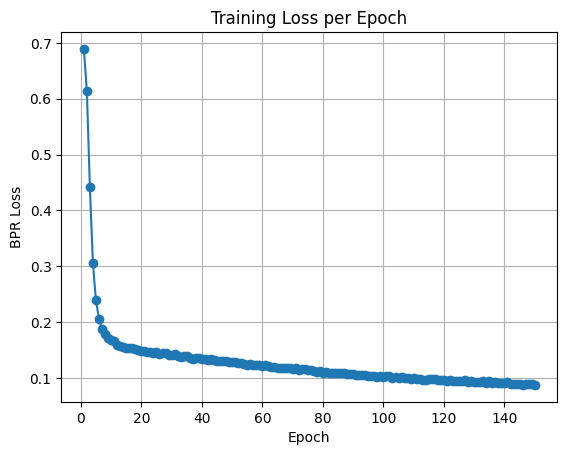

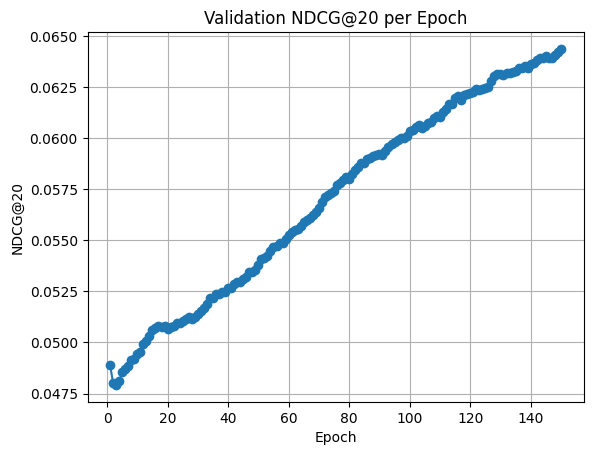

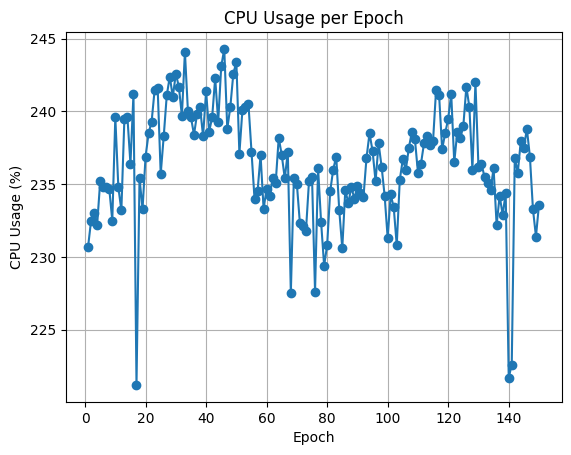

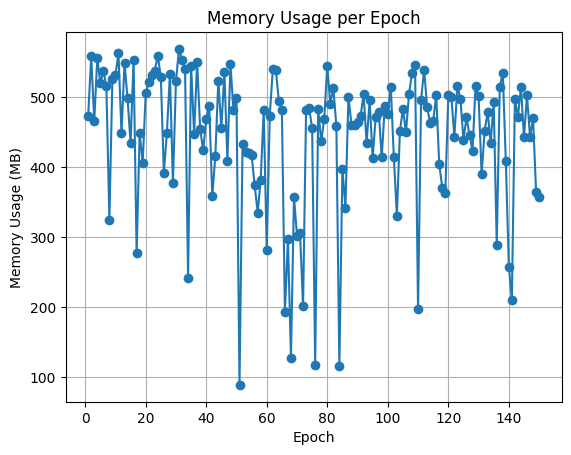

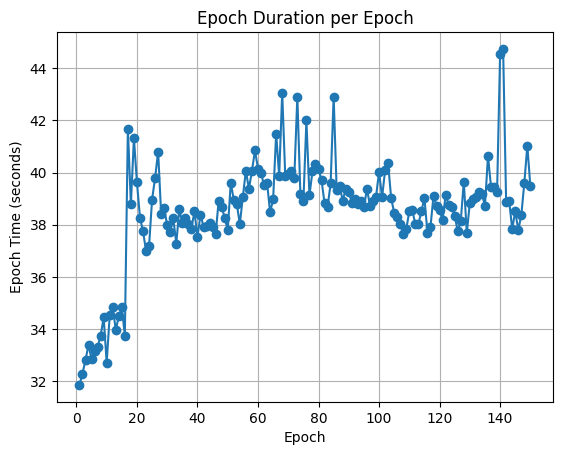

In [14]:
# Plot training curves and system usage using 'history'
epochs = history["epoch"]

plt.figure()
plt.plot(epochs, history["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history["ndcg@20"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("NDCG@20")
plt.title("Validation NDCG@20 per Epoch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history["cpu_percent"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("CPU Usage (%)")
plt.title("CPU Usage per Epoch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history["memory_mb"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage per Epoch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, history["epoch_time_sec"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Epoch Time (seconds)")
plt.title("Epoch Duration per Epoch")
plt.grid(True)
plt.show()

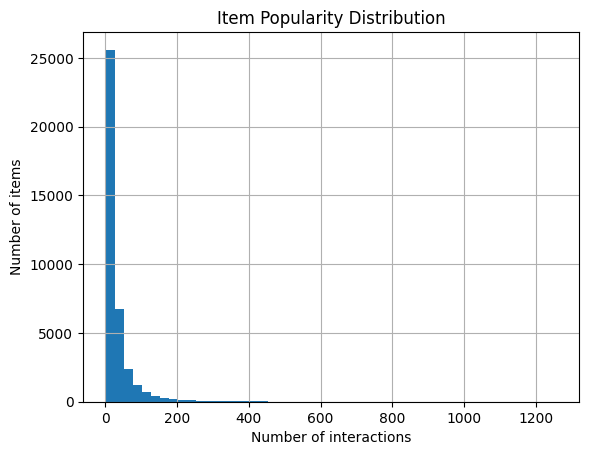

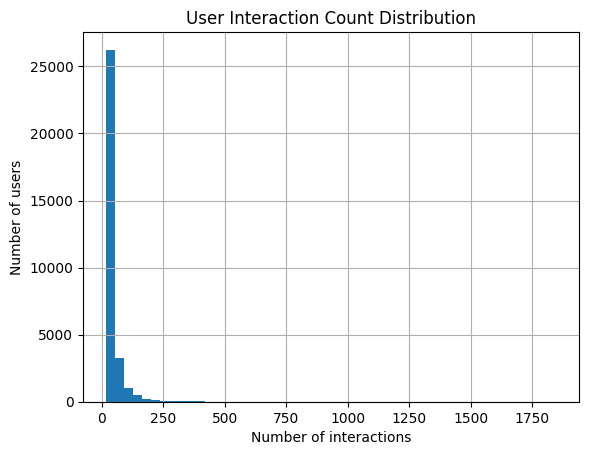

In [15]:
# Histogram of item popularity
plt.figure()
plt.hist(item_popularity[item_popularity > 0], bins=50)
plt.xlabel("Number of interactions")
plt.ylabel("Number of items")
plt.title("Item Popularity Distribution")
plt.grid(True)
plt.show()

# Histogram of user interaction counts
user_interactions = np.array([len(user_items.get(u, [])) for u in range(num_users)])
plt.figure()
plt.hist(user_interactions[user_interactions > 0], bins=50)
plt.xlabel("Number of interactions")
plt.ylabel("Number of users")
plt.title("User Interaction Count Distribution")
plt.grid(True)
plt.show()